**TITLE: Amazon Prime Video EDA : AI-Driven Movie Success Prediction using Merged Datasets**

**Problem Statement**

The entertainment industry generates a large amount of movie-related data, but it is often spread across multiple datasets such as movie details and credits. This makes it difficult to analyze the data effectively and extract meaningful insights. Additionally, predicting whether a movie will be successful is a complex task influenced by various factors like ratings, votes, and runtime.

This project aims to merge multiple datasets, analyze the data using exploratory data analysis (EDA), and build a machine learning model to predict movie success, enabling data-driven decision-making

**SUMMARY**
The project, “Amazon Prime Video Analytics: EDA & AI-Driven Movie Success Prediction using Merged Datasets”, focuses on analyzing movie data by combining multiple datasets and using machine learning to predict whether a movie will be successful.

In this project, we first merge datasets containing movie details and credits, then perform exploratory data analysis (EDA) to understand patterns, and finally build a machine learning model to predict movie success.

**KEY INSIGHTS**:
*   **Data Merging & Preparation**: We take data from different files and join them into one complete table so that all information about a movie is available in one place.
*   **Exploratory Data Analysis (EDA)**: We study the data using graphs to understand which movies have higher ratings, how votes and runtime affect success and whether there are any unusual values (outliers). This helps us discover patterns, understand relationships,make better decisions before modeling.
*   **Machine Learning for Prediction**: We train a model using past movie data so that it can predict if a new movie will be successful. Create a target variable (success),train the model (Logistic Regression)and evaluate accuracy.

**Conclusion**

This project shows how merging datasets and performing EDA helps in understanding movie data and identifying key patterns. It highlights that movies with higher ratings and votes are more likely to succeed. Using machine learning, we built a model that can predict movie success, demonstrating the power of data-driven decision-making in the entertainment industry.





**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Here, we are importing the required libraries:


*   pandas → to handle data
*   numpy → for numerical operations
*   matplotlib & seaborn → for graphs and visualizations

**Load Dataset**

In [3]:
credits = pd.read_csv('/content/credits.csv')
titles = pd.read_csv('/content/titles.csv')

We load both datasets into the notebook credits contains cast & crew details
titles contains movie information

**View Data**

In [4]:
#Displays first 5 rows
credits.head()
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


**Data Info**

In [5]:
credits.info()
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   in

Shows columns, data types, and missing values and helps in planning data cleaning.

**Merge Data**

In [13]:
df = pd.merge(titles, credits, on='id')
df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


In [16]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Total rows: 124347
Total columns: 19


**Check Missing Values**

In [22]:
df.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
imdb_id,5303


In [29]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score',
       'person_id', 'name', 'character', 'role'],
      dtype='object')


**Drop Useless**

In [30]:
print("Before dropping column:", df.shape)

if 'seasons' in df.columns:
    df = df.drop(['seasons'], axis=1)
    print("Column 'seasons' dropped")
else:
    print("Column 'seasons' not found")

print("After operation:", df.shape)

Before dropping column: (119029, 18)
Column 'seasons' not found
After operation: (119029, 18)


In [33]:
print("Missing values BEFORE filling:\n")
print(df[['imdb_score','imdb_votes','tmdb_score']].isnull().sum())


df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].mean())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())

print("\nMissing values AFTER filling:\n")
print(df[['imdb_score','imdb_votes','tmdb_score']].isnull().sum())

Missing values BEFORE filling:

imdb_score    0
imdb_votes    0
tmdb_score    0
dtype: int64

Missing values AFTER filling:

imdb_score    0
imdb_votes    0
tmdb_score    0
dtype: int64


**Fill categorical**

In [35]:
print("Missing values BEFORE filling:\n")
print(df[['age_certification','character','description']].isnull().sum())

df['age_certification'] = df['age_certification'].fillna('Unknown')
df['character'] = df['character'].fillna('Unknown')
df['description'] = df['description'].fillna('No description')

print("\nMissing values AFTER filling:\n")
print(df[['age_certification','character','description']].isnull().sum())

Missing values BEFORE filling:

age_certification    0
character            0
description          0
dtype: int64

Missing values AFTER filling:

age_certification    0
character            0
description          0
dtype: int64


**Drop Missing**

In [37]:
print("Missing values BEFORE dropping:\n")
print(df['imdb_id'].isnull().sum())

# Drop rows where imdb_id is missing
df = df.dropna(subset=['imdb_id'])

print("\nMissing values AFTER dropping:\n")
print(df['imdb_id'].isnull().sum())

print("\nDataset shape after dropping:", df.shape)

Missing values BEFORE dropping:

0

Missing values AFTER dropping:

0

Dataset shape after dropping: (119029, 18)


**Box Plot**

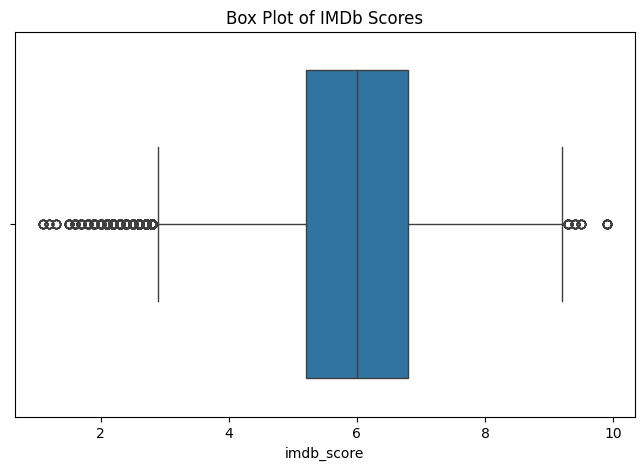

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['imdb_score'])
plt.title("Box Plot of IMDb Scores")
plt.show()

The box plot of IMDb scores shows that most movies have ratings concentrated within a specific range, indicating consistency in movie quality. The median rating lies around the central region of the box, suggesting that the typical movie has an average rating. The presence of outliers on both the lower and higher ends indicates that there are a few movies with exceptionally low or exceptionally high ratings compared to the majority. This variation highlights that while most movies perform within a standard range, some movies significantly deviate from the norm.

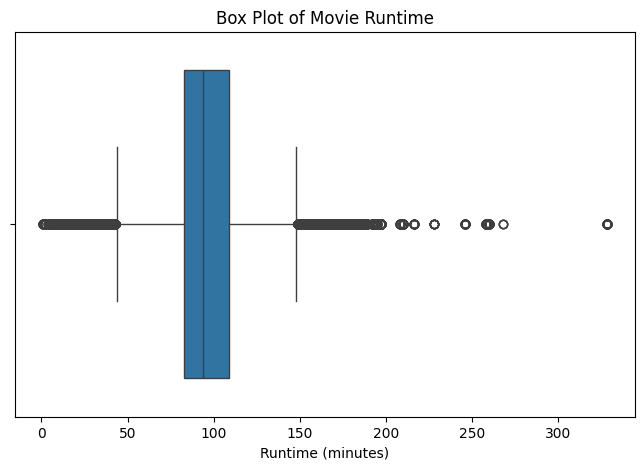

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['runtime'])
plt.title("Box Plot of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.show()

*   The box area shows where most movie runtimes are concentrated
*   The whiskers indicate the overall spread of runtimes
*   Outliers represent movies that are much shorter or longer than usual
*  Most movies fall within a standard runtime range (around 90–120 minutes)
*   A few movies are extremely long or short, indicating special cases






In [39]:
print("Min IMDb Score:", df['imdb_score'].min())
print("Max IMDb Score:", df['imdb_score'].max())

Min IMDb Score: 1.1
Max IMDb Score: 9.9


**HISTOGRAM**

IMDb Score Histogram

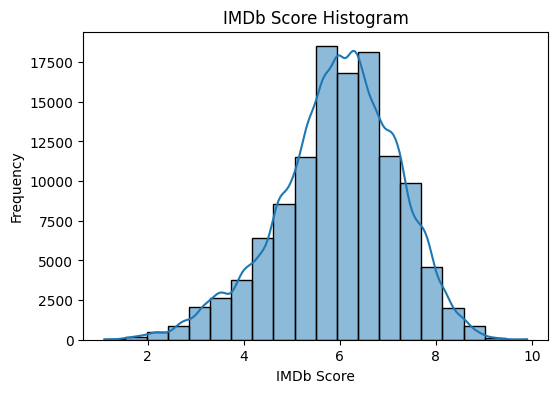

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title("IMDb Score Histogram")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")
plt.show()

This histogram shows how IMDb scores are distributed across all movies in the dataset. The bars represent the number of movies falling within specific rating ranges, while the smooth curve helps us understand the overall trend more clearly. From the graph, we can observe that most movies have ratings between 6 and 7, indicating that average-rated movies are more common, while very high and very low ratings are less frequent.

**Release Year Histogram**

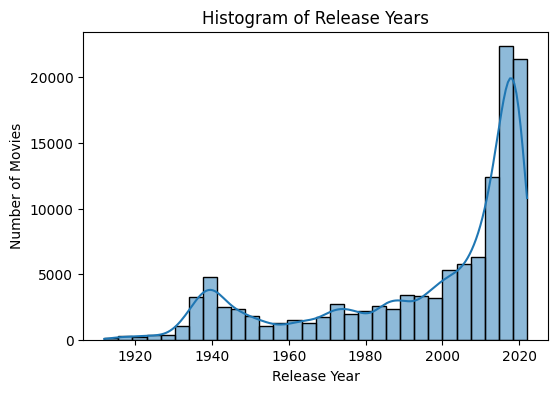

In [48]:
plt.figure(figsize=(6,4))
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title("Histogram of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

This histogram shows how movies are distributed across different years. It helps us understand how many movies were released in each time period. From the graph, we can see whether the number of movies has increased or decreased over time.

**Machine Learning**

**Aim**: In the machine learning part, we aim to build a model that can predict whether a movie will be successful or not based on its features. We use the cleaned dataset and select important columns such as ratings, votes, and runtime. Then, we train a model using past data so that it can learn patterns and make predictions on new data.

**Feature Selection**

In [51]:
df['success'] = (df['imdb_score'] >= 7.0).astype(int)

X = df[['imdb_votes', 'runtime', 'tmdb_score']]
y = df['success']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (119029, 3)
Target shape: (119029,)


We created a target variable called success based on IMDb score and selected important features like votes, runtime, and ratings for prediction.

**Train-Test Split**

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (95223, 3)
Testing data shape: (23806, 3)


*  We split the dataset into training and testing data
*  test_size=0.2 → 20% data for testing
*  random_state=42 → ensures same split every time
We split the dataset into training and testing sets, where 80% is used for training the model and 20% is used for evaluating its performance.

**Train Model**

In [53]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model training completed")

Model training completed


*   We use Logistic Regression, a classification algorithm
*   model.fit() trains the model using training data

**Make Prediction**

In [54]:
y_pred = model.predict(X_test)
print("Predictions done")

Predictions done


**Evaluate Model**

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8529362345627153

Confusion Matrix:
 [[17754   791]
 [ 2710  2551]]


Accuracy → how many predictions are correct
Example: 0.82 = 82% correct predictions

Confusion Matrix shows:
*   Correct predictions
*   Wrong predictions


